# Testing Multiple Resolutions
Now that we have a function to bin at multiple resolutions and to set a threshold, we can test values and computation time for these multiple resolutions and thresholds.

## Importing and Binning Data

In [1]:
### Importing Cooler Files ###
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import ot
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, generate_related_contact_map, bin_contact_map, get_cool_name, hic_ot_source_to_targets

# Setting directory for saving
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/ot_bulk_res'

# Importing data
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic'
coolers = import_cool_dir(data_dir, 1_000_000)

# Extracting chromosome 1
chr1s = []
map_names = []
for clr in coolers:
    chr1s.append(fetch_region(clr, '1'))
    map_names.append(get_cool_name(clr).split("_")[1])

In [2]:
### Binning First Chromosomes ###
resolutions = [1, 2, 4, 8]
clp1 = chr1s[9]
clp1_binned_list = []

for res in resolutions:
    clp1_binned_list.append(bin_contact_map(clp1, res))

In [22]:
### Generating Related Maps ###
similarities = [0.99, 0.9, 0.75, 0.5, 0.25, 0.1, 0.01, 0.001]
percentiles = [0, 5, 10, 25, 50, 75, 90]
clp_related_list = []

    # Generate a list of related contact maps for each resolution
for clp in clp1_binned_list:
    clp_related = []

    for sim in similarities:
        clp_related.append(generate_related_contact_map(clp, base_decay=0.75, similarity=sim, seed = 106))

    clp_related_list.append(clp_related)

## Exact OT

### 8 Mb

In [4]:
### Exact OT ###
exact_values_list_8mb = []
exact_times_8mb = []

for percentile in percentiles:
    start_time = time.perf_counter()
    if percentile == 0:
        exact_values_list_8mb.append(hic_ot_source_to_targets(clp1_binned_list[3], clp_related_list[3], percentile, 'raw', 'max'))
    else:
        exact_values_list_8mb.append(hic_ot_source_to_targets(clp1_binned_list[3], clp_related_list[3], percentile, 'percentile', 'max'))
    end_time = time.perf_counter()
    exact_times_8mb.append({
        "Percentile": percentile,
        "Time": end_time - start_time
    })

In [5]:
### Convert Results to Dataframe and Save ###
exact_times_8mb_df = pd.DataFrame(exact_times_8mb)
exact_times_8mb_df.to_csv(f'{save_dir}/exact_times_4mb.csv', index=False)
exact_times_8mb_df

,Percentile,Time
0,0,0.044950
1,5,0.031807
2,10,0.031345
3,25,0.018089
4,50,0.008403
5,75,0.002510
6,90,0.001114


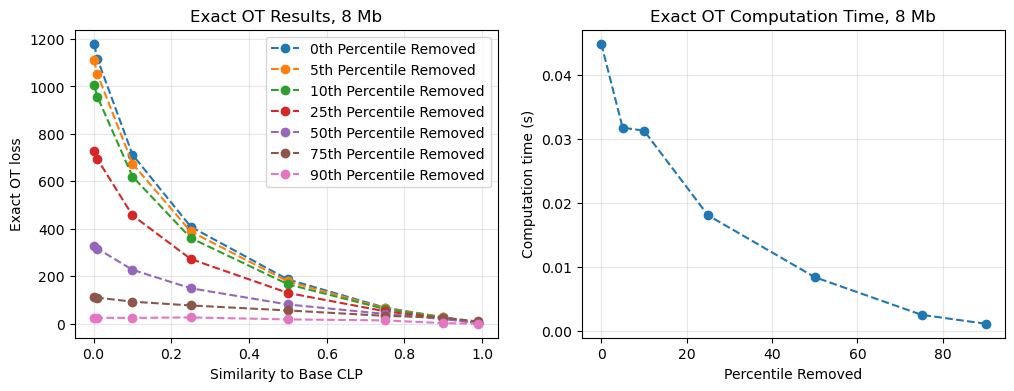

In [6]:
### Plotting Results and Times ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OT results
for ot_values, percentile in zip(exact_values_list_8mb, percentiles):
    axes[0].plot(similarities, ot_values, 'o--', label=f"{percentile}th Percentile Removed")
axes[0].set_xlabel("Similarity to Base CLP")
axes[0].set_ylabel("Exact OT loss")
axes[0].set_title("Exact OT Results, 8 Mb")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Times
axes[1].plot(percentiles, exact_times_8mb_df["Time"], 'o--')
axes[1].set_xlabel("Percentile Removed")
axes[1].set_ylabel("Computation time (s)")
axes[1].set_title("Exact OT Computation Time, 8 Mb")
axes[1].grid(alpha=0.3)

plt.show()

### 4 Mb

In [7]:
### Exact OT ###
exact_values_list_4mb = []
exact_times_4mb = []

for percentile in percentiles:
    start_time = time.perf_counter()
    if percentile == 0:
        exact_values_list_4mb.append(hic_ot_source_to_targets(clp1_binned_list[2], clp_related_list[2], percentile, 'raw', 'max'))
    else:
        exact_values_list_4mb.append(hic_ot_source_to_targets(clp1_binned_list[2], clp_related_list[2], percentile, 'percentile', 'max'))
    end_time = time.perf_counter()
    exact_times_4mb.append({
        "Percentile": percentile,
        "Time": end_time - start_time
    })

In [8]:
### Convert Results to Dataframe and Save ###
exact_times_4mb_df = pd.DataFrame(exact_times_4mb)
exact_times_4mb_df.to_csv(f'{save_dir}/exact_times_4mb.csv', index=False)
exact_times_4mb_df

,Percentile,Time
0,0,1.160768
1,5,1.030900
2,10,1.031429
3,25,0.943571
4,50,0.192841
5,75,0.033421
6,90,0.005880


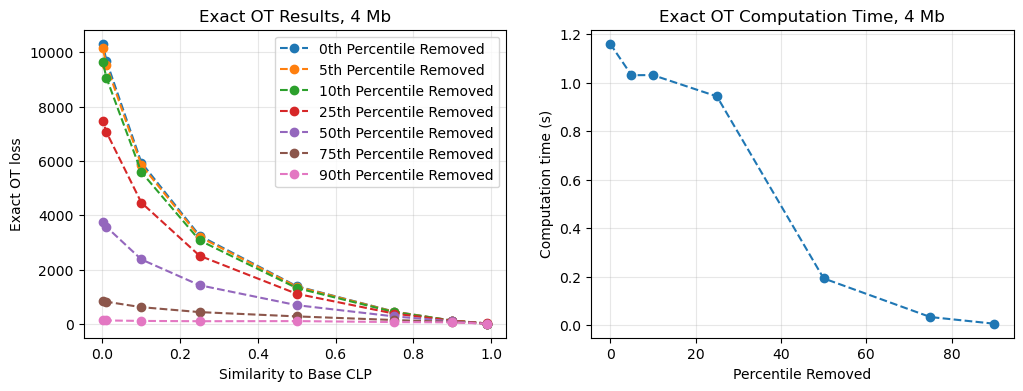

In [9]:
### Plotting Results and Times ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OT results
for ot_values, percentile in zip(exact_values_list_4mb, percentiles):
    axes[0].plot(similarities, ot_values, 'o--', label=f"{percentile}th Percentile Removed")
axes[0].set_xlabel("Similarity to Base CLP")
axes[0].set_ylabel("Exact OT loss")
axes[0].set_title("Exact OT Results, 4 Mb")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Times
axes[1].plot(percentiles, exact_times_4mb_df["Time"], 'o--')
axes[1].set_xlabel("Percentile Removed")
axes[1].set_ylabel("Computation time (s)")
axes[1].set_title("Exact OT Computation Time, 4 Mb")
axes[1].grid(alpha=0.3)

plt.show()

### 2 Mb

In [10]:
### Exact OT ###
exact_values_list_2mb = []
exact_times_2mb = []

for percentile in percentiles:
    start_time = time.perf_counter()
    if percentile == 0:
        exact_values_list_2mb.append(hic_ot_source_to_targets(clp1_binned_list[1], clp_related_list[1], percentile, 'raw', 'max'))
    else:
        exact_values_list_2mb.append(hic_ot_source_to_targets(clp1_binned_list[1], clp_related_list[1], percentile, 'percentile', 'max'))
    end_time = time.perf_counter()
    exact_times_2mb.append({
        "Percentile": percentile,
        "Time": end_time - start_time
    })

In [11]:
### Convert Results to Dataframe and Save ###
exact_times_2mb_df = pd.DataFrame(exact_times_2mb)
exact_times_2mb_df.to_csv(f'{save_dir}/exact_times_2mb.csv', index=False)
exact_times_2mb_df

,Percentile,Time
0,0,28.389343
1,5,17.018183
2,10,17.031564
3,25,12.717607
4,50,4.348986
5,75,1.182700
6,90,0.088239


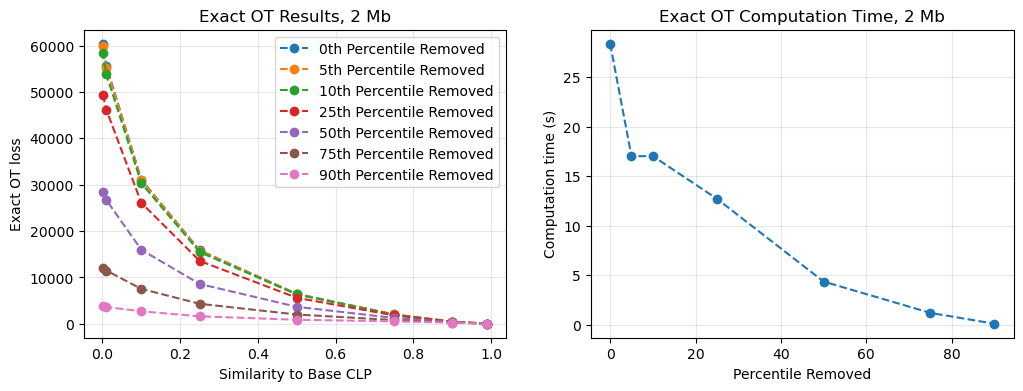

In [12]:
### Plotting Results and Times ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OT results
for ot_values, percentile in zip(exact_values_list_2mb, percentiles):
    axes[0].plot(similarities, ot_values, 'o--', label=f"{percentile}th Percentile Removed")
axes[0].set_xlabel("Similarity to Base CLP")
axes[0].set_ylabel("Exact OT loss")
axes[0].set_title("Exact OT Results, 2 Mb")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Times
axes[1].plot(percentiles, exact_times_2mb_df["Time"], 'o--')
axes[1].set_xlabel("Percentile Removed")
axes[1].set_ylabel("Computation time (s)")
axes[1].set_title("Exact OT Computation Time, 2 Mb")
axes[1].grid(alpha=0.3)

plt.show()

### 1 Mb

In [53]:
### Exact OT ###
exact_values_list_1mb = []
exact_times_1mb = []

for percentile in percentiles:
    start_time = time.perf_counter()
    if percentile == 0:
        exact_values_list_1mb.append(hic_ot_source_to_targets(clp1_binned_list[0], clp_related_list[0], percentile, 'raw', 'max'))
    else:
        exact_values_list_1mb.append(hic_ot_source_to_targets(clp1_binned_list[0], clp_related_list[0], percentile, 'percentile', 'max'))
    end_time = time.perf_counter()
    exact_times_1mb.append({
        "Percentile": percentile,
        "Time": end_time - start_time
    })

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/lp/_network_simplex.py:520: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


In [54]:
### Convert Results to Dataframe and Save ###
exact_times_1mb_df = pd.DataFrame(exact_times_1mb)
exact_times_1mb_df.to_csv(f'{save_dir}/exact_times_1mb.csv', index=False)
exact_times_1mb_df

,Percentile,Time
0,0,1084.621675
1,5,838.935766
2,10,578.668367
3,25,279.861983
4,50,79.090304
5,75,13.551628
6,90,1.531248


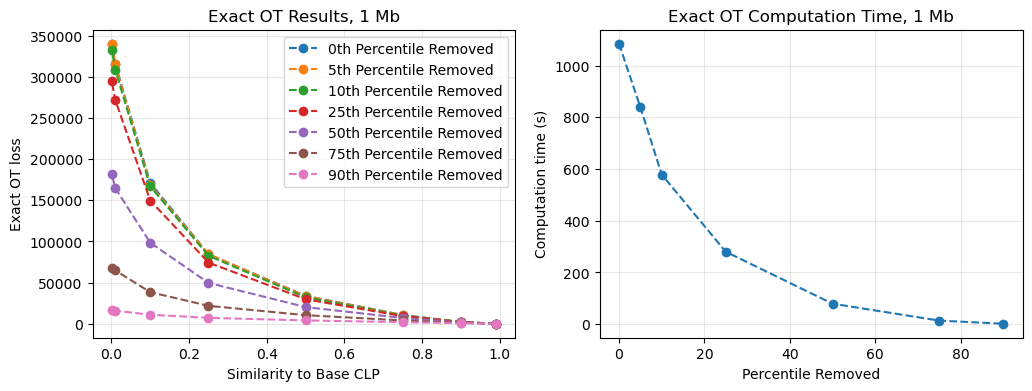

In [55]:
### Plotting Results and Times ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OT results
for ot_values, percentile in zip(exact_values_list_1mb, percentiles):
    axes[0].plot(similarities, ot_values, 'o--', label=f"{percentile}th Percentile Removed")
axes[0].set_xlabel("Similarity to Base CLP")
axes[0].set_ylabel("Exact OT loss")
axes[0].set_title("Exact OT Results, 1 Mb")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Times
axes[1].plot(percentiles, exact_times_1mb_df["Time"], 'o--')
axes[1].set_xlabel("Percentile Removed")
axes[1].set_ylabel("Computation time (s)")
axes[1].set_title("Exact OT Computation Time, 1 Mb")
axes[1].grid(alpha=0.3)

plt.show()

## Unbalanced OT

In [41]:
### Set unbalanced parameter ###
reg_m = 5e-1

### 8 Mb

In [48]:
### UOT ###
uot_values_list_8mb = []
uot_times_8mb = []

for percentile in percentiles:
    start_time = time.perf_counter()
    if percentile == 0:
        uot_values_list_8mb.append(hic_ot_source_to_targets(clp1_binned_list[3], clp_related_list[3], percentile, 'raw', 'max', reg_m))
    else:
        uot_values_list_8mb.append(hic_ot_source_to_targets(clp1_binned_list[3], clp_related_list[3], percentile, 'percentile', 'max', reg_m))
    end_time = time.perf_counter()
    uot_times_8mb.append({
        "Percentile": percentile,
        "Time": end_time - start_time
    })

In [49]:
### Convert Results to Dataframe and Save ###
uot_times_8mb_df = pd.DataFrame(uot_times_8mb)
uot_times_8mb_df.to_csv(f'{save_dir}/uot_times_8mb.csv', index=False)
uot_times_8mb_df

,Percentile,Time
0,0,0.757724
1,5,0.879551
2,10,1.734657
3,25,1.443891
4,50,1.073354
5,75,0.194014
6,90,0.041288


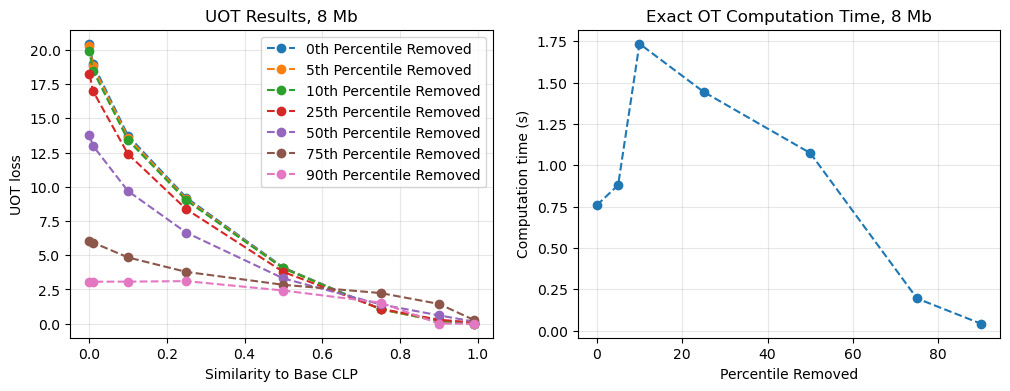

In [50]:
### Plotting Results and Times ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OT results
for ot_values, percentile in zip(uot_values_list_8mb, percentiles):
    axes[0].plot(similarities, ot_values, 'o--', label=f"{percentile}th Percentile Removed")
axes[0].set_xlabel("Similarity to Base CLP")
axes[0].set_ylabel("UOT loss")
axes[0].set_title("UOT Results, 8 Mb")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Times
axes[1].plot(percentiles, uot_times_8mb_df["Time"], 'o--')
axes[1].set_xlabel("Percentile Removed")
axes[1].set_ylabel("Computation time (s)")
axes[1].set_title("Exact OT Computation Time, 8 Mb")
axes[1].grid(alpha=0.3)

plt.show()

### 4 Mb

In [45]:
### UOT ###
uot_values_list_4mb = []
uot_times_4mb = []

for percentile in percentiles:
    start_time = time.perf_counter()
    if percentile == 0:
        uot_values_list_4mb.append(hic_ot_source_to_targets(clp1_binned_list[2], clp_related_list[2], percentile, 'raw', 'max', reg_m))
    else:
        uot_values_list_4mb.append(hic_ot_source_to_targets(clp1_binned_list[2], clp_related_list[2], percentile, 'percentile', 'max', reg_m))
    end_time = time.perf_counter()
    uot_times_4mb.append({
        "Percentile": percentile,
        "Time": end_time - start_time
    })

In [46]:
### Convert Results to Dataframe and Save ###
uot_times_4mb_df = pd.DataFrame(uot_times_4mb)
uot_times_4mb_df.to_csv(f'{save_dir}/uot_times_4mb.csv', index=False)
uot_times_4mb_df

,Percentile,Time
0,0,13.079288
1,5,37.694141
2,10,34.261131
3,25,25.453032
4,50,8.520377
5,75,2.141444
6,90,0.920724


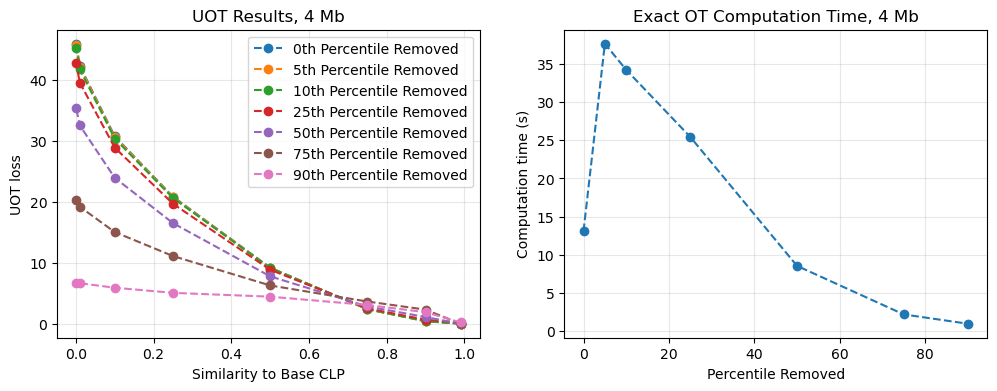

In [47]:
### Plotting Results and Times ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OT results
for ot_values, percentile in zip(uot_values_list_4mb, percentiles):
    axes[0].plot(similarities, ot_values, 'o--', label=f"{percentile}th Percentile Removed")
axes[0].set_xlabel("Similarity to Base CLP")
axes[0].set_ylabel("UOT loss")
axes[0].set_title("UOT Results, 4 Mb")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Times
axes[1].plot(percentiles, uot_times_4mb_df["Time"], 'o--')
axes[1].set_xlabel("Percentile Removed")
axes[1].set_ylabel("Computation time (s)")
axes[1].set_title("Exact OT Computation Time, 4 Mb")
axes[1].grid(alpha=0.3)

plt.show()

## Determining Dependence on Cost Matrix Size
For both exact and unbalanced OT, we have determined general trends for computation time. However, we have yet to determine how this computation time depends on the number of elements in each calculation. We will determine this for both exact OT and unbalanced OT.

### Exact OT

In [7]:
### Exact OT ###
exact_sizes_list = []
exact_times_list = []

for clp_binned, clp_related in zip(clp1_binned_list[1:4], clp_related_list[1:4]):
    for percentile in percentiles:
        start_time = time.perf_counter()
        if percentile == 0:
            size = hic_ot_source_to_targets(clp_binned, clp_related, percentile, 'raw', 'max', return_size=True)[1]
        else:
            size = hic_ot_source_to_targets(clp_binned, clp_related, percentile, 'percentile', 'max', return_size=True)[1]
        end_time = time.perf_counter()
        
        exact_sizes_list.append(size)
        exact_times_list.append(end_time-start_time)

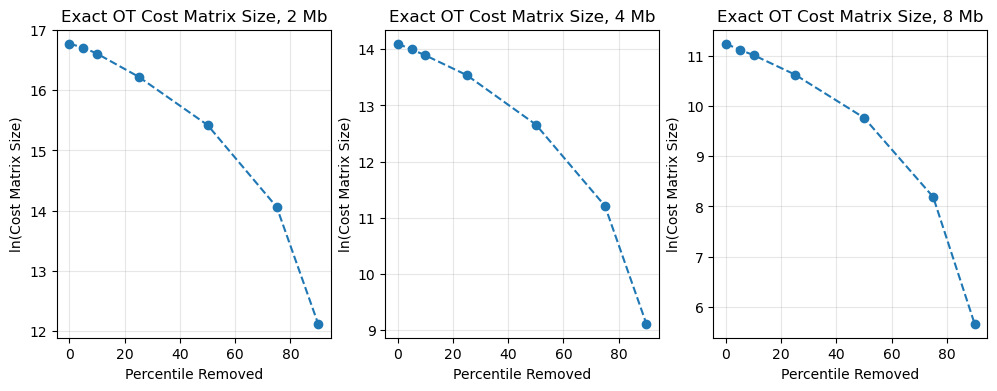

In [30]:
### Plotting percentile and cost matrix size ###
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 2 Mb
axes[0].plot(percentiles, np.log(exact_sizes_list[0:7]), 'o--')
axes[0].set_xlabel("Percentile Removed")
axes[0].set_ylabel("ln(Cost Matrix Size)")
axes[0].set_title("Exact OT Cost Matrix Size, 2 Mb")
axes[0].grid(alpha=0.3)

# 4 Mb
axes[1].plot(percentiles, np.log(exact_sizes_list[7:14]), 'o--')
axes[1].set_xlabel("Percentile Removed")
axes[1].set_ylabel("ln(Cost Matrix Size)")
axes[1].set_title("Exact OT Cost Matrix Size, 4 Mb")
axes[1].grid(alpha=0.3)

# 8 Mb
axes[2].plot(percentiles, np.log(exact_sizes_list[14:21]), 'o--')
axes[2].set_xlabel("Percentile Removed")
axes[2].set_ylabel("ln(Cost Matrix Size)")
axes[2].set_title("Exact OT Cost Matrix Size, 8 Mb")
axes[2].grid(alpha=0.3)

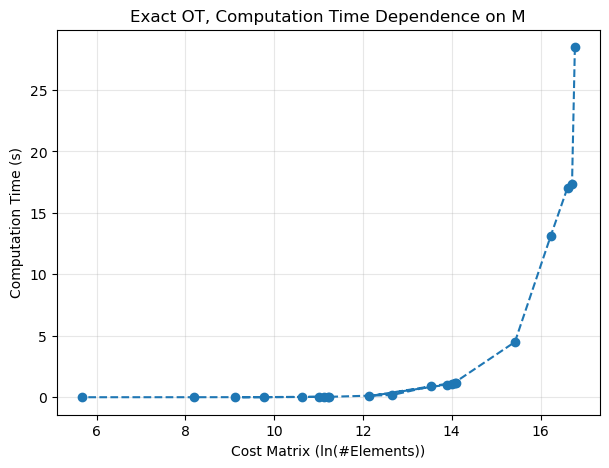

In [9]:
### Plotting ###
plt.figure(figsize=(7, 5))
plt.plot(np.log(exact_sizes_list), exact_times_list, 'o--')
plt.xlabel("Cost Matrix (ln(#Elements))")
plt.ylabel("Computation Time (s)")
plt.title("Exact OT, Computation Time Dependence on M")
plt.grid(alpha=0.3)
plt.show()

### Unbalanced OT

In [11]:
### Exact OT ###
uot_sizes_list = []
uot_times_list = []
reg_m = 5e-1

for clp_binned, clp_related in zip(clp1_binned_list[2:4], clp_related_list[2:4]):
    for percentile in percentiles:
        start_time = time.perf_counter()
        if percentile == 0:
            size = hic_ot_source_to_targets(clp_binned, clp_related, percentile, 'raw', 'max', reg_m, return_size=True)[1]
        else:
            size = hic_ot_source_to_targets(clp_binned, clp_related, percentile, 'percentile', 'max', reg_m, return_size=True)[1]
        end_time = time.perf_counter()
        
        uot_sizes_list.append(size)
        uot_times_list.append(end_time-start_time)

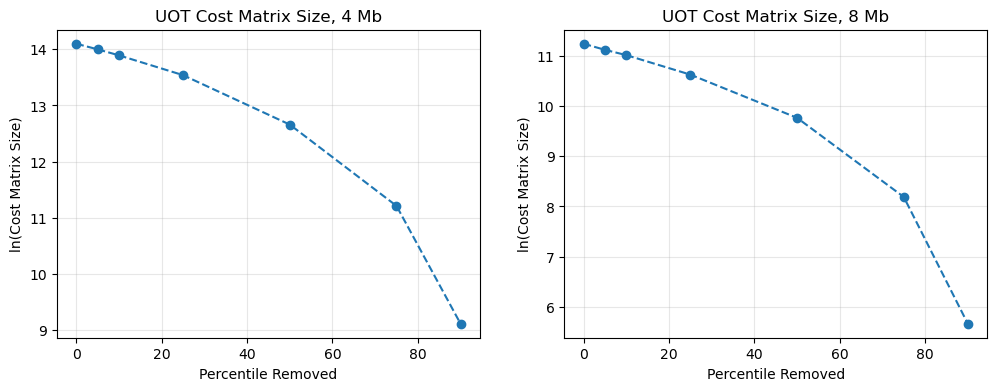

In [33]:
### Plotting percentile and cost matrix size ###
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 4 Mb
axes[0].plot(percentiles, np.log(uot_sizes_list[0:7]), 'o--')
axes[0].set_xlabel("Percentile Removed")
axes[0].set_ylabel("ln(Cost Matrix Size)")
axes[0].set_title("UOT Cost Matrix Size, 4 Mb")
axes[0].grid(alpha=0.3)

# 8 Mb
axes[1].plot(percentiles, np.log(uot_sizes_list[7:14]), 'o--')
axes[1].set_xlabel("Percentile Removed")
axes[1].set_ylabel("ln(Cost Matrix Size)")
axes[1].set_title("UOT Cost Matrix Size, 8 Mb")
axes[1].grid(alpha=0.3)

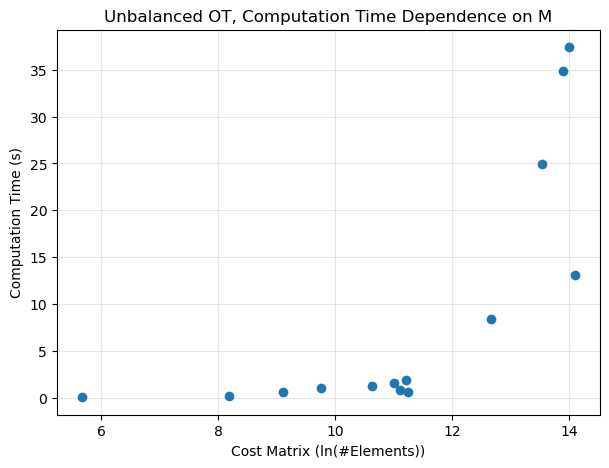

In [14]:
### Plotting ###
plt.figure(figsize=(7, 5))
plt.plot(np.log(uot_sizes_list), uot_times_list, 'o')
plt.xlabel("Cost Matrix (ln(#Elements))")
plt.ylabel("Computation Time (s)")
plt.title("Unbalanced OT, Computation Time Dependence on M")
plt.grid(alpha=0.3)
plt.show()